In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import plotly.express as px
from loguru import logger
import geopy
import reverse_geocode
import pycountry_convert as pc

from tqdm import tqdm
from loguru import logger
# from metrics import get_metrics
mapbox_access_token = open(".mapbox_token").read()
px.set_mapbox_access_token(mapbox_access_token)

In [2]:
# Iterate over all train/val/test samples
root = '/scratch/workspace/rdaroya_umass_edu-water2/hls_data/multitask_data_opera_v2/'
suffix = "108knew"
train_fps_path = os.path.join(root, f'train_{suffix}.npy')
with open(train_fps_path, "rb") as f:
    npzfile = np.load(f, allow_pickle=True)
    train_fps = npzfile["fps"]

val_fps_path = os.path.join(root, f'val_{suffix}.npy')
with open(val_fps_path, "rb") as f:
    npzfile = np.load(f, allow_pickle=True)
    val_fps = npzfile["fps"]

test_fps_path = os.path.join(root, f'test_{suffix}.npy')
with open(test_fps_path, "rb") as f:
    npzfile = np.load(f, allow_pickle=True)
    test_fps = npzfile["fps"]

In [4]:
len(train_fps), len(val_fps), len(test_fps), train_fps[0]

(82247,
 12849,
 12154,
 '/scratch/workspace/rdaroya_umass_edu-water/hls_data/multitask_data_opera_v2/b368/5914_T17WPN_00.npy')

In [5]:
# Check that there's no overlap in files
for f in train_fps:
    if f in val_fps:
        logger.error(f'val : {f}')
    if f in test_fps:
        logger.error(f'test : {f}')

for f in val_fps:
    if f in test_fps:
        logger.error(f'test : {f}')

In [7]:
geog_data = []

for fp in tqdm(train_fps):
    fp = fp.replace("rdaroya_umass_edu-water", "rdaroya_umass_edu-water2")
    with open(fp, "rb") as f:
        npzfile = np.load(f, allow_pickle=True)
        # opera_sat = npzfile["opera_sat"]
        tile_id = npzfile["tile_id"]
        water_mask = np.sum(npzfile["water_mask"])
        snowice_mask = np.sum(npzfile["snowice_mask"])
        cloudshadow_mask = np.sum(npzfile["cloudshadow_mask"])
        sun_mask = np.sum(npzfile["sun_mask"])
        cloud_mask = np.sum(npzfile["cloud_mask"])
        lat, lon = npzfile["mid_latlon"]
        datetime_str = npzfile["date_str"]
        geog_data.append([fp, lat, lon, tile_id, water_mask, snowice_mask, cloudshadow_mask, sun_mask, cloud_mask,datetime_str, "train"])

for fp in tqdm(val_fps):
    fp = fp.replace("rdaroya_umass_edu-water", "rdaroya_umass_edu-water2")
    with open(fp, "rb") as f:
        npzfile = np.load(f, allow_pickle=True)
        # opera_sat = npzfile["opera_sat"]
        tile_id = npzfile["tile_id"]
        water_mask = np.sum(npzfile["water_mask"])
        snowice_mask = np.sum(npzfile["snowice_mask"])
        cloudshadow_mask = np.sum(npzfile["cloudshadow_mask"])
        sun_mask = np.sum(npzfile["sun_mask"])
        cloud_mask = np.sum(npzfile["cloud_mask"])
        lat, lon = npzfile["mid_latlon"]
        datetime_str = npzfile["date_str"]
        geog_data.append([fp, lat, lon, tile_id, water_mask, snowice_mask, cloudshadow_mask, sun_mask, cloud_mask,datetime_str, "val"])


for fp in tqdm(test_fps):
    fp = fp.replace("rdaroya_umass_edu-water", "rdaroya_umass_edu-water2")
    with open(fp, "rb") as f:
        npzfile = np.load(f, allow_pickle=True)
        # opera_sat = npzfile["opera_sat"]
        tile_id = npzfile["tile_id"]
        water_mask = np.sum(npzfile["water_mask"])
        snowice_mask = np.sum(npzfile["snowice_mask"])
        cloudshadow_mask = np.sum(npzfile["cloudshadow_mask"])
        sun_mask = np.sum(npzfile["sun_mask"])
        cloud_mask = np.sum(npzfile["cloud_mask"])
        lat, lon = npzfile["mid_latlon"]
        datetime_str = npzfile["date_str"]
        geog_data.append([fp, lat, lon, tile_id, water_mask, snowice_mask, cloudshadow_mask, sun_mask, cloud_mask,datetime_str, "test"])

100%|██████████| 12154/12154 [17:02<00:00, 11.89it/s]


In [8]:
# geog_df = pd.DataFrame(geog_data, columns=["fp", "lat", "lon", "tile_id", "water_mask", "snowice_mask", "cloudshadow_mask", "sun_mask", "cloud_mask", "datetime", "set"])
# geog_df.to_csv(f"data_distrib_{suffix}_withdatetime.csv", index=False)

In [9]:
# Plot geographic locations of all thos with snow/ice data (>0 snow/ice pixels)

In [3]:
geog_df = pd.read_csv(f"data_distrib_{suffix}_withdatetime.csv")
geog_df.shape

(107250, 11)

In [4]:
geog_df["set"].value_counts()

set
train    82247
val      12849
test     12154
Name: count, dtype: int64

In [5]:
snowice_data = geog_df[geog_df["snowice_mask"]>0.1*(512*512)]   # 10k pixels is ~3% of an image patch
snowice_data.shape

(11393, 11)

/tmp/ipykernel_1456707/2381609897.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_1456707/2381609897.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



   month   snowice_mask
0     01   92544.898759
1     02  134296.074754
2     03  154699.341853
3     04  215217.445517
4     05  132271.571142
5     06   75789.984009
6     07   54925.197413
7     08   28230.442770
8     09   29571.979228
9     10   33881.807457
10    11   45229.879347
11    12   52514.358934
   month  snowice_mask
0     01   4283.933419
1     02   3803.603386
2     03   1892.171233
3     04   3613.105023
4     05   6475.376827
5     06   4370.740519
6     07   8437.455709
7     08   6365.974244
8     09   6540.363911
9     10   9460.609871
10    11   8453.652757
11    12   8702.804668


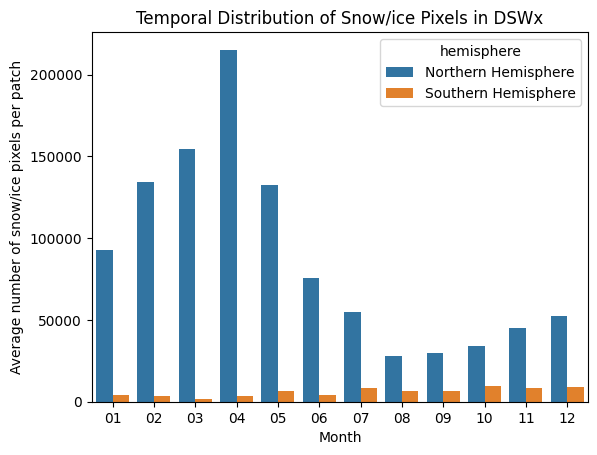

In [123]:
# Plot the months where there are nonzero snow/ice pixels
upper_hemis_snowice = geog_df[((geog_df["lat"]>0)&(geog_df["snowice_mask"]>0))]
lower_hemis_snowice = geog_df[((geog_df["lat"]<0)&(geog_df["snowice_mask"]>0))]

upper_hemis_snowice['month'] = upper_hemis_snowice.apply(lambda row: row["datetime"].split("T")[0][4:6], axis=1)
lower_hemis_snowice['month'] = lower_hemis_snowice.apply(lambda row: row["datetime"].split("T")[0][4:6], axis=1)

# accumulate number of snowice pixels per month
masks = ["snowice_mask"]
for m in masks:
    # north_df = upper_hemis_snowice[[m, "month"]].groupby("month").agg(["sum","mean","median"]).reset_index()
    north_df = upper_hemis_snowice[[m, "month"]].groupby("month").agg("mean").reset_index()
    print(north_df)
north_df["hemisphere"] = "Northern Hemisphere"
# sns.barplot(data=north_df, x="month", y="snowice_mask", color="green")
# plt.title("Distribution of snow/ice pixels in the Northern Hemisphere per month")
# plt.ylabel("Average number of snow/ice pixels per patch")
# plt.xlabel("Month")


masks = ["snowice_mask"]
for m in masks:
    # south_df = lower_hemis_snowice[[m, "month"]].groupby("month").agg(["sum","mean","median"]).reset_index()
    south_df = lower_hemis_snowice[[m, "month"]].groupby("month").agg("mean").reset_index()
    print(south_df)
south_df["hemisphere"] = "Southern Hemisphere"
sns.barplot(data=south_df, x="month", y="snowice_mask")
# plt.title("Distribution of snow/ice pixels in the Southern Hemisphere per month")
# plt.ylabel("Average number of snow/ice pixels per patch")
# plt.xlabel("Month")

combined_df = pd.concat([north_df, south_df])
# sns.catplot(kind='bar', data=combined_df, x='month', y='snowice_mask', col='hemisphere')
sns.barplot(data=combined_df, x='month', y='snowice_mask', hue='hemisphere')

plt.ylabel("Average number of snow/ice pixels per patch")
plt.xlabel("Month")
plt.title("Temporal Distribution of Snow/ice Pixels in DSWx")
plt.savefig("snowice_distrib_per_month.pdf", bbox_inches="tight", dpi=150)

In [55]:
fig = px.scatter_mapbox(snowice_data, lon='lon', lat='lat',    color="set", #size="car_hours", 
    
    hover_data=["tile_id", "snowice_mask", "datetime"],
    color_continuous_scale=px.colors.cyclical.IceFire, 
    title="Snow/ice Train/val/test geographic distribution",
    color_continuous_midpoint=0,
)
fig.update_layout(
    autosize=True,
    hovermode='closest',
    mapbox=dict(
        accesstoken=mapbox_access_token,
        bearing=0,
        center=dict(
            lat=38.92,
            lon=-77.07
        ),
        pitch=0,
        zoom=1
    ),
)
fig.show()

# Plot Maps

In [56]:
geog_df

,fp,lat,lon,tile_id,water_mask,snowice_mask,cloudshadow_mask,sun_mask,cloud_mask,datetime,set
0,/scratch/workspace/rdaroya_umass_edu-water2/hl...,65.288336,-77.615732,T17WPN,0,2431,16287,588162,565372,20240303T165109Z,train
1,/scratch/workspace/rdaroya_umass_edu-water2/hl...,65.288336,-77.615732,T17WPN,0,0,0,588082,589824,20230809T165849Z,train
2,/scratch/workspace/rdaroya_umass_edu-water2/hl...,65.288336,-77.615732,T17WPN,0,0,40017,588164,530171,20230717T164849Z,train
3,/scratch/workspace/rdaroya_umass_edu-water2/hl...,66.218105,-82.022912,T17WMP,0,2690,2373,589824,583993,20230908T165849Z,train
4,/scratch/workspace/rdaroya_umass_edu-water2/hl...,-33.904443,150.364294,T56HKH,6193,0,99971,436835,447929,20231026T000219Z,train
...,...,...,...,...,...,...,...,...,...,...,...
107245,/scratch/workspace/rdaroya_umass_edu-water2/hl...,29.309693,-107.535987,T13RBN,0,0,9,572359,0,20230913T174618Z,test
107246,/scratch/workspace/rdaroya_umass_edu-water2/hl...,29.309693,-107.535987,T13RBN,71,218,13676,586934,15231,20230423T173909Z,test
107247,/scratch/workspace/rdaroya_umass_edu-water2/hl...,29.309693,-107.535987,T13RBN,0,0,54660,559032,461157,20240227T174259Z,test
107248,/scratch/workspace/rdaroya_umass_edu-water2/hl...,29.309693,-107.535987,T13RBN,57,248,12739,585748,12727,20230418T173901Z,test


In [57]:
# def get_color(x):
#     if x=="train":
#         return "green"
#     elif x=="val":
#         return "violet"
#     else:
#         return "yellow"
# geog_df['color'] = geog_df['set'].map(lambda x: get_color(x))

In [6]:
import pandas as pd
from shapely.geometry import Point
import geopandas as gpd
from geopandas import GeoDataFrame


def get_set(x):
    if x=="val":
        return "validation"
    return x
snowice_data['set'] = snowice_data['set'].map(lambda x: get_set(x))
geometry = [Point(xy) for xy in zip(snowice_data['lon'], snowice_data['lat'])]
gdf = GeoDataFrame(snowice_data, geometry=geometry)   



/tmp/ipykernel_2670624/139014336.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  snowice_data['set'] = snowice_data['set'].map(lambda x: get_set(x))


/tmp/ipykernel_2670624/2156097233.py:5: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


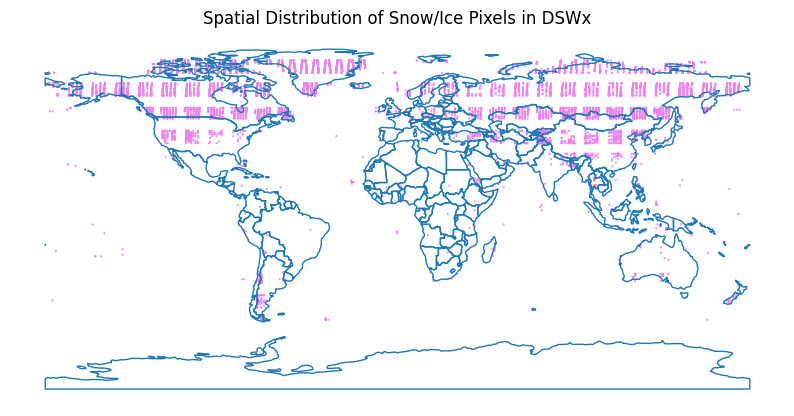

In [7]:
import matplotlib
from matplotlib.colors import LinearSegmentedColormap

#this is a simple map that goes with geopandas
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
# cmap = LinearSegmentedColormap.from_list(
#     'mycmap', [(0, 'green'), (1, 'blue'), (2, 'red')])
palette = {'train': 'violet', 'validation': 'violet', 'test' : 'violet'}
cmap = matplotlib.colors.ListedColormap([palette[b] for b in snowice_data.set.unique()])

ax = world.boundary.plot(figsize=(10, 6), linewidth=1)
gdf.plot(ax=ax, marker='.', column="set", cmap=cmap, markersize=1, legend=False, categorical=True, legend_kwds={'loc': 'lower right'})  # green, violet, yellow
# leg = ax.get_legend()
# leg.set_bbox_to_anchor((0., 0., 0.2, 0.2))
# loc='upper center', bbox_to_anchor=(0.5, -0.05),
#           fancybox=True, shadow=True, ncol=5
# ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05),
#           fancybox=True, shadow=False, ncol=3)

# ax.legend(loc='lower center', fontsize=12, frameon=True) 
# leg = ax.get_legend()
# leg.set_bbox_to_anchor((0.5, 0))
# leg.set_ncols(3)
# plt.legend(ncol=3, loc='lower center', fontsize="x-large")
plt.axis('off')
plt.title("Spatial Distribution of Snow/Ice Pixels in DSWx")
plt.savefig("data-distribution_snowice.pdf", bbox_inches="tight", dpi=150)
plt.show()


In [8]:
# Check distribution of train/val/test data (geographic)

# Plot number of samples

In [9]:
# Check number of pixels per label in train/val/test (and number of tiles with certain number of pixels)